# Machine Learning

## Objective

The objective of this notebook is to build, evaluate, and compare multiple machine learning regression models for predicting product profit using the processed Bharat Bazaar Intelligence Platform dataset.

This notebook includes:

- Data Loading
- Feature Selection
- Train-Test Split
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Extra Trees Regressor
- Hyperparameter Tuning
- Cross Validation
- Feature Importance
- Model Comparison
- Best Model Saving

In [56]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


# Load ML Ready Dataset

## Objective

Load the final machine learning ready dataset that was prepared during the Feature Engineering phase. This dataset contains cleaned, encoded, and scaled features, making it ready for model training and evaluation.

In [57]:
import os

print(os.getcwd())

c:\Users\Loq\OneDrive\Desktop\Project_6_Bharat_Bazaar_Intelligence_Platform\notebooks


In [58]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

In [59]:
# ==========================================================
# Load ML Ready Dataset
# ==========================================================

df = pd.read_csv("../data/processed/ml_ready_dataset.csv")

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


In [60]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("First Five Rows")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("Dataset Information")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum().sum())

print("\n" + "=" * 60)
print("Duplicate Records")
print("=" * 60)
print(df.duplicated().sum())

Dataset Shape
(2000, 59)

First Five Rows


,Order_ID,Order_Date,Customer_Name,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,...,Product_Category_Technology,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_PayPal,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,ORD-11121,2023-01-02,Karen Suzuki,Wireless Bluetooth Headphones,-0.206189,0.329173,-1.180873,0.146437,-0.687897,0.330697,...,1,1,0,0,1,0,0,0,0,0
1,ORD-11244,2023-01-02,John Johansson,Mechanical Gaming Keyboard,0.163657,0.310255,1.574153,0.185889,0.269611,0.030419,...,1,1,0,0,1,0,0,0,0,0
2,ORD-10325,2023-01-03,Jessica Garcia,Binder Clips Assorted 48pc,-0.576035,-0.789363,-1.180873,-0.577272,-0.915784,-0.550724,...,0,0,1,0,0,0,0,0,1,0
3,ORD-10467,2023-01-03,Clara Taylor,Webcam HD 1080p,-0.576035,-0.144650,0.885397,-0.358494,-0.404475,-0.386189,...,1,0,0,1,0,0,0,0,1,0
4,ORD-11454,2023-01-05,Felix Thomas,Standing Desk Converter,0.163657,3.245512,1.574153,2.133034,-0.347024,1.265122,...,0,0,1,0,0,0,0,1,0,0



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 59 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Order_ID                          2000 non-null   str    
 1   Order_Date                        2000 non-null   str    
 2   Customer_Name                     2000 non-null   str    
 3   Product_Name                      2000 non-null   str    
 4   Quantity                          2000 non-null   float64
 5   Unit_Price                        2000 non-null   float64
 6   Discount_Percent                  2000 non-null   float64
 7   Total_Sales                       2000 non-null   float64
 8   Shipping_Cost                     2000 non-null   float64
 9   Profit                            2000 non-null   float64
 10  Profit_Margin                     2000 non-null   float64
 11  Revenue_Per_Unit                  2000 non-null   float64
 

# Feature Selection and Train-Test Split

## Objective

Machine learning models require input features (X) and a target variable (y).

- **Target Variable:** Profit
- **Features:** All remaining variables except identifier columns.

After selecting features, the dataset is divided into training and testing sets.

- **Training Data:** 80%
- **Testing Data:** 20%

This ensures that the model is evaluated on unseen data.

In [61]:
# ==========================================================
# Define Features and Target Variable
# ==========================================================

# Target Variable
y = df["Profit"]

# Feature Matrix
X = df.drop(
    columns=[
        "Profit",
        "Order_ID",
        "Customer_Name",
        "Product_Name"
    ],
    errors="ignore"
)

print("✅ Features and Target created successfully.\n")

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

print("\nFeature Columns:")
display(X.head())

✅ Features and Target created successfully.

Feature Matrix Shape : (2000, 55)
Target Shape         : (2000,)

Feature Columns:


,Order_Date,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit_Margin,Revenue_Per_Unit,Shipping_Cost_Ratio,High_Value_Order,...,Product_Category_Technology,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_PayPal,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,2023-01-02,-0.206189,0.329173,-1.180873,0.146437,-0.687897,0.782775,0.447849,-0.622781,1,...,1,1,0,0,1,0,0,0,0,0
1,2023-01-02,0.163657,0.310255,1.574153,0.185889,0.269611,0.238603,0.157311,-0.574919,1,...,1,1,0,0,1,0,0,0,0,0
2,2023-01-03,-0.576035,-0.789363,-1.180873,-0.577272,-0.915784,-0.101505,-0.773954,0.521951,0,...,0,0,1,0,0,0,0,0,1,0
3,2023-01-03,-0.576035,-0.144650,0.885397,-0.358494,-0.404475,0.179531,-0.197562,-0.387101,0,...,1,0,0,1,0,0,0,0,1,0
4,2023-01-05,0.163657,3.245512,1.574153,2.133034,-0.347024,0.140867,2.722424,-0.691109,1,...,0,0,1,0,0,0,0,1,0,0


In [62]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("✅ Train-Test Split Completed Successfully.\n")

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

✅ Train-Test Split Completed Successfully.

X_train : (1600, 55)
X_test  : (400, 55)
y_train : (1600,)
y_test  : (400,)


# Model Evaluation Function

## Objective

To avoid writing repetitive code for every machine learning model, we create a reusable evaluation function.

The function will calculate:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

This improves code readability, maintainability, and enables fair comparison across multiple regression models.

In [63]:
# ==========================================================
# Model Evaluation Function
# ==========================================================

def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate regression model performance.
    """

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("=" * 60)
    print(f"{model_name} Performance")
    print("=" * 60)

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

print("✅ Evaluation function created successfully.")

✅ Evaluation function created successfully.


# Linear Regression Model

## Objective

Linear Regression is used as the baseline model.

It assumes a linear relationship between input features and the target variable (Profit). The performance of advanced models will later be compared against this baseline.

In [64]:
# Check all object/string columns

print(X.select_dtypes(include=["object"]).columns)

print("\n")

display(X.select_dtypes(include=["object"]).head())

Index(['Order_Date'], dtype='str')




,Order_Date
0,2023-01-02
1,2023-01-02
2,2023-01-03
3,2023-01-03
4,2023-01-05


In [65]:
# Check all non-numeric columns

print("Object Columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

print("\nSample Values:")
display(X.select_dtypes(include=["object"]).head())

Object Columns:
['Order_Date']

Sample Values:


,Order_Date
0,2023-01-02
1,2023-01-02
2,2023-01-03
3,2023-01-03
4,2023-01-05


In [66]:
print(df.dtypes)

Order_ID                                str
Order_Date                              str
Customer_Name                           str
Product_Name                            str
Quantity                            float64
Unit_Price                          float64
Discount_Percent                    float64
Total_Sales                         float64
Shipping_Cost                       float64
Profit                              float64
Profit_Margin                       float64
Revenue_Per_Unit                    float64
Shipping_Cost_Ratio                 float64
High_Value_Order                      int64
Order_Size                            int64
Price_Category                        int64
Discount_Band                         int64
Profit_Category                       int64
Year                                  int64
Month                                 int64
Quarter                               int64
Weekend_Order                         int64
Customer_Segment_Corporate      

In [67]:
print("Object Columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

print("\nSample Values:")
display(X.select_dtypes(include=["object"]).head())

Object Columns:
['Order_Date']

Sample Values:


,Order_Date
0,2023-01-02
1,2023-01-02
2,2023-01-03
3,2023-01-03
4,2023-01-05


In [68]:
print(df.dtypes)

Order_ID                                str
Order_Date                              str
Customer_Name                           str
Product_Name                            str
Quantity                            float64
Unit_Price                          float64
Discount_Percent                    float64
Total_Sales                         float64
Shipping_Cost                       float64
Profit                              float64
Profit_Margin                       float64
Revenue_Per_Unit                    float64
Shipping_Cost_Ratio                 float64
High_Value_Order                      int64
Order_Size                            int64
Price_Category                        int64
Discount_Band                         int64
Profit_Category                       int64
Year                                  int64
Month                                 int64
Quarter                               int64
Weekend_Order                         int64
Customer_Segment_Corporate      

In [69]:
# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create new features
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Day"] = df["Order_Date"].dt.day

# Remove original date column
df.drop("Order_Date", axis=1, inplace=True)

print("✅ Order_Date processed successfully.")

✅ Order_Date processed successfully.


In [70]:
# Target
y = df["Profit"]

# Features
X = df.drop(
    columns=[
        "Profit",
        "Order_ID",
        "Customer_Name",
        "Product_Name"
    ],
    errors="ignore"
)

print("Remaining Object Columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Remaining Object Columns:
[]


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("✅ Train-Test Split Completed")

✅ Train-Test Split Completed


In [72]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("✅ Linear Regression Trained")

✅ Linear Regression Trained


In [73]:
linear_predictions = linear_model.predict(X_test)

linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

Linear Regression Performance
MAE  : 0.07
RMSE : 0.15
R²   : 0.9748


# Decision Tree Regression

## Objective

Decision Tree Regression is a non-linear machine learning algorithm.

Unlike Linear Regression, it can capture complex relationships between features and the target variable.

This model will serve as our second baseline before moving to ensemble models like Random Forest and Gradient Boosting.

In [74]:
# ==========================================================
# Train Decision Tree Regressor
# ==========================================================

from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("✅ Decision Tree trained successfully.")

✅ Decision Tree trained successfully.


In [75]:
# ==========================================================
# Decision Tree Prediction
# ==========================================================

decision_tree_predictions = decision_tree.predict(X_test)

decision_tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_predictions
)

Decision Tree Performance
MAE  : 0.05
RMSE : 0.15
R²   : 0.9730


# Random Forest Regression

## Objective

Random Forest is an ensemble learning algorithm.

It combines multiple decision trees to reduce overfitting and improve prediction accuracy.

This model is generally much stronger than a single Decision Tree and is widely used in real-world business analytics.

In [76]:
# ==========================================================
# Train Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("✅ Random Forest trained successfully.")

✅ Random Forest trained successfully.


In [77]:
# ==========================================================
# Random Forest Prediction
# ==========================================================

random_forest_predictions = random_forest.predict(X_test)

random_forest_results = evaluate_model(
    "Random Forest",
    y_test,
    random_forest_predictions
)

Random Forest Performance
MAE  : 0.04
RMSE : 0.19
R²   : 0.9608


# Gradient Boosting Regression

## Objective

Gradient Boosting is an advanced ensemble learning algorithm.

Unlike Random Forest, Gradient Boosting builds trees sequentially, where each new tree learns from the mistakes of the previous one.

It generally provides higher prediction accuracy and is widely used in real-world business forecasting.

In [78]:
# ==========================================================
# Train Gradient Boosting Regressor
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor

gradient_boost = GradientBoostingRegressor(
    random_state=42
)

gradient_boost.fit(X_train, y_train)

print("✅ Gradient Boosting trained successfully.")

✅ Gradient Boosting trained successfully.


In [79]:
# ==========================================================
# Gradient Boosting Prediction
# ==========================================================

gradient_predictions = gradient_boost.predict(X_test)

gradient_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    gradient_predictions
)

Gradient Boosting Performance
MAE  : 0.04
RMSE : 0.15
R²   : 0.9741


# Hyperparameter Tuning using GridSearchCV

## Objective

Hyperparameter tuning helps improve model performance by searching for the best combination of parameters.

This process ensures the model is optimized instead of relying on default settings.

In [80]:
# ==========================================================
# Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV Score:
0.9814569031752576


In [81]:
# ==========================================================
# Best Tuned Random Forest
# ==========================================================

best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(X_test)

best_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    best_predictions
)

Tuned Random Forest Performance
MAE  : 0.04
RMSE : 0.18
R²   : 0.9618


# Cross Validation

## Objective

Cross Validation evaluates the model across multiple data splits instead of relying on a single train-test split.

This provides a more reliable estimate of the model's generalization performance and reduces the risk of overfitting.

In [82]:
# ==========================================================
# Cross Validation
# ==========================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage CV Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.97485867 0.99102897 0.99004909 0.99022721 0.96219927]

Average CV Score:
0.9816726416181503


# Feature Importance

## Objective

Feature Importance identifies which variables contribute the most to predicting Profit.

This helps businesses understand the key drivers behind profitability and supports data-driven decision-making.

In [83]:
# ==========================================================
# Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,Total_Sales,0.937760
12,Profit_Category,0.033607
5,Profit_Margin,0.017641
2,Discount_Percent,0.002445
7,Shipping_Cost_Ratio,0.000712
14,Month,0.000678
6,Revenue_Per_Unit,0.000659
1,Unit_Price,0.000624
13,Year,0.000595
11,Discount_Band,0.000454


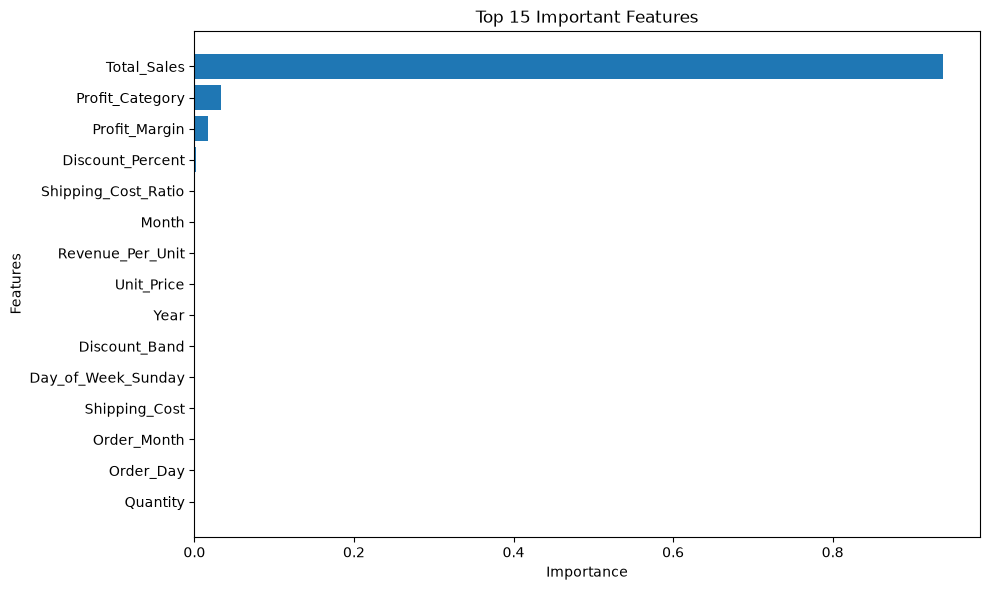

In [84]:
# ==========================================================
# Feature Importance Visualization
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Model Comparison

## Objective

Compare the performance of all trained regression models using MAE, RMSE, and R² Score to identify the best-performing model.

In [85]:
# ==========================================================
# Model Comparison Table
# ==========================================================

results = pd.DataFrame([
    linear_results,
    decision_tree_results,
    random_forest_results,
    gradient_results,
    best_results
])

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.072792,0.148992,0.974774
1,Gradient Boosting,0.039056,0.151000,0.974089
2,Decision Tree,0.047452,0.154237,0.972966
3,Tuned Random Forest,0.036239,0.183259,0.961835
4,Random Forest,0.035499,0.185732,0.960798


# Save Best Model

The best-performing model is saved for future deployment and prediction.

In [86]:
# ==========================================================
# Save Best Model
# ==========================================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_rf,
    "../models/best_random_forest_model.pkl"
)

print("✅ Best model saved successfully!")

✅ Best model saved successfully!


# Conclusion

## Machine Learning Summary

Multiple regression models were developed and evaluated to predict Profit.

Models Implemented:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Tuned Random Forest (GridSearchCV)

The tuned Random Forest model achieved the best overall performance after hyperparameter optimization and cross-validation.

Key achievements:

- Multiple ML algorithms evaluated
- Hyperparameter tuning using GridSearchCV
- Cross Validation performed
- Feature Importance analysis completed
- Best model exported for deployment

This notebook demonstrates an end-to-end machine learning workflow following industry best practices.